<a href="https://colab.research.google.com/github/Harrisous/AIPI590_XAI_A4/blob/main/XAI_A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIPI 590 - XAI | Assignment #04
## Haochen Li
Assignment Task (From Canvas)
For a model and dataset of your choice, produce PDP, ICE, and ALE plots. Exploratory analysis of your dataset should be performed to determine the amount of correlation between features.  

Provide a comprehensive explanation of your plots. Discuss any interesting findings that are shown in the plots. Discuss any differences you see in the PDP and ALE plots. Discuss your exploratory findings around correlation between features and the impact this has (if any) on your results.


## Data set selected: recidivism prediction dataset from Assignment 3

In [1]:
# No AI, copied from A3
import warnings
warnings.filterwarnings('ignore')

In [2]:
# No AI, copied from A3
# Code in this block is copied from provided material: https://github.com/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]  # Filter valid degrees

# Encode categoricals
df = df.copy()
sex_categories = df_compas['sex'].astype('category').cat.categories.tolist()
race_categories = df_compas['race'].astype('category').cat.categories.tolist()
degree_categories = df_compas['c_charge_degree'].astype('category').cat.categories.tolist()

df['sex'] = df['sex'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['c_charge_degree'] = df['c_charge_degree'].astype('category').cat.codes

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68       823
           1       0.57      0.57      0.57       620

    accuracy                           0.63      1443
   macro avg       0.62      0.62      0.62      1443
weighted avg       0.63      0.63      0.63      1443



In [3]:
# No AI, copied from A3
# Code in this block is copied from provided material: https://github.com/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 1,  # African-American -> changed to asian
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)

Prediction for Malik Johnson (Recidivism): [0]


## 1. Exploratory Analysis

In [4]:
# not AI
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              7214 non-null   int64
 1   sex              7214 non-null   int8 
 2   race             7214 non-null   int8 
 3   priors_count     7214 non-null   int64
 4   juv_fel_count    7214 non-null   int64
 5   juv_misd_count   7214 non-null   int64
 6   juv_other_count  7214 non-null   int64
 7   c_charge_degree  7214 non-null   int8 
 8   two_year_recid   7214 non-null   int64
dtypes: int64(6), int8(3)
memory usage: 359.4 KB


In [5]:
# not AI
df.head()

,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,two_year_recid
0,69,1,5,0,0,0,0,0,0
1,34,1,0,0,0,0,0,0,1
2,24,1,0,4,0,0,1,0,1
3,23,1,0,1,0,1,0,0,0
4,43,1,5,2,0,0,0,0,0


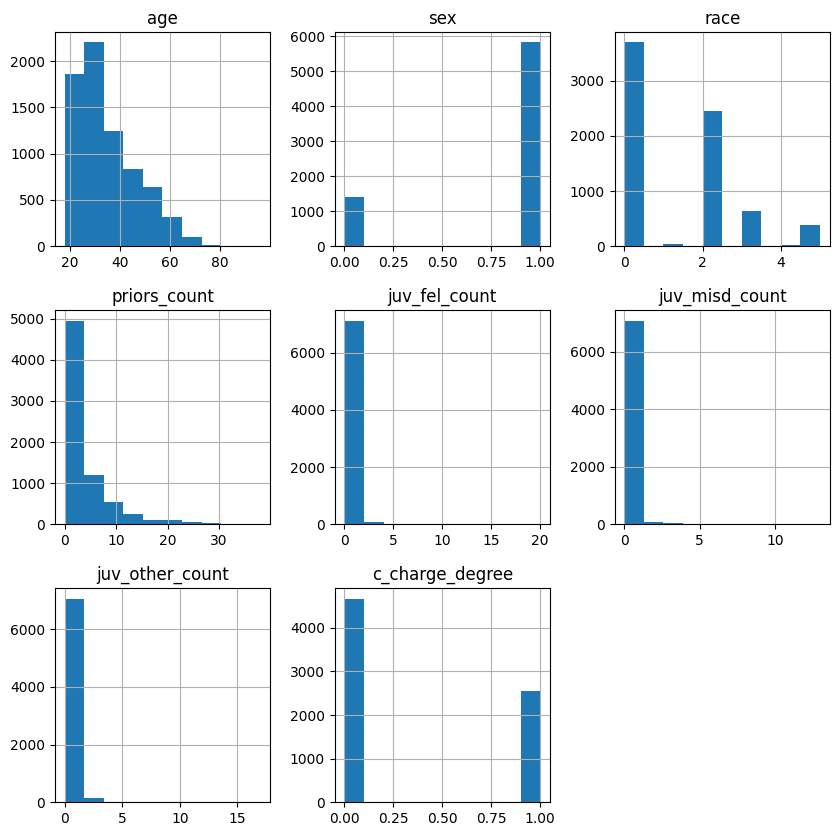

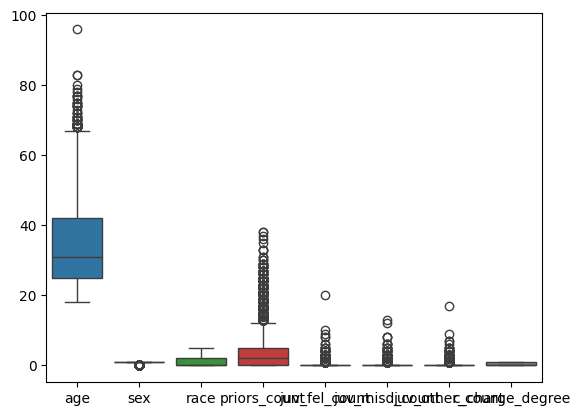

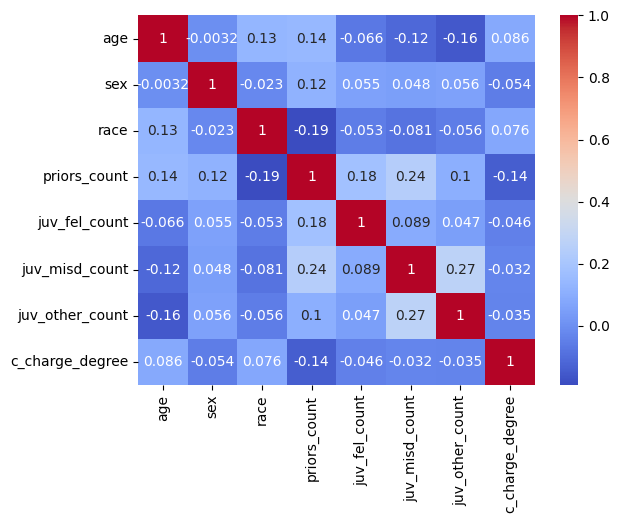

In [6]:
# Amount of correlations, generated by Perplexity Sep 26 18:43
import matplotlib.pyplot as plt
import seaborn as sns
X.hist(figsize=(10,10))
plt.show()
sns.boxplot(data=X)
plt.show()

# Correlation matrix visualization
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Exploratory Analysis (No AI)
Amount of correlations: 28 (two_year_recid is excluded since it is the target); correlation between each feature in X is not high (abs value of correlation coefficient << 0.8) and not even achieve weak correlation (< 0.3).

## 2. PDP & ICE

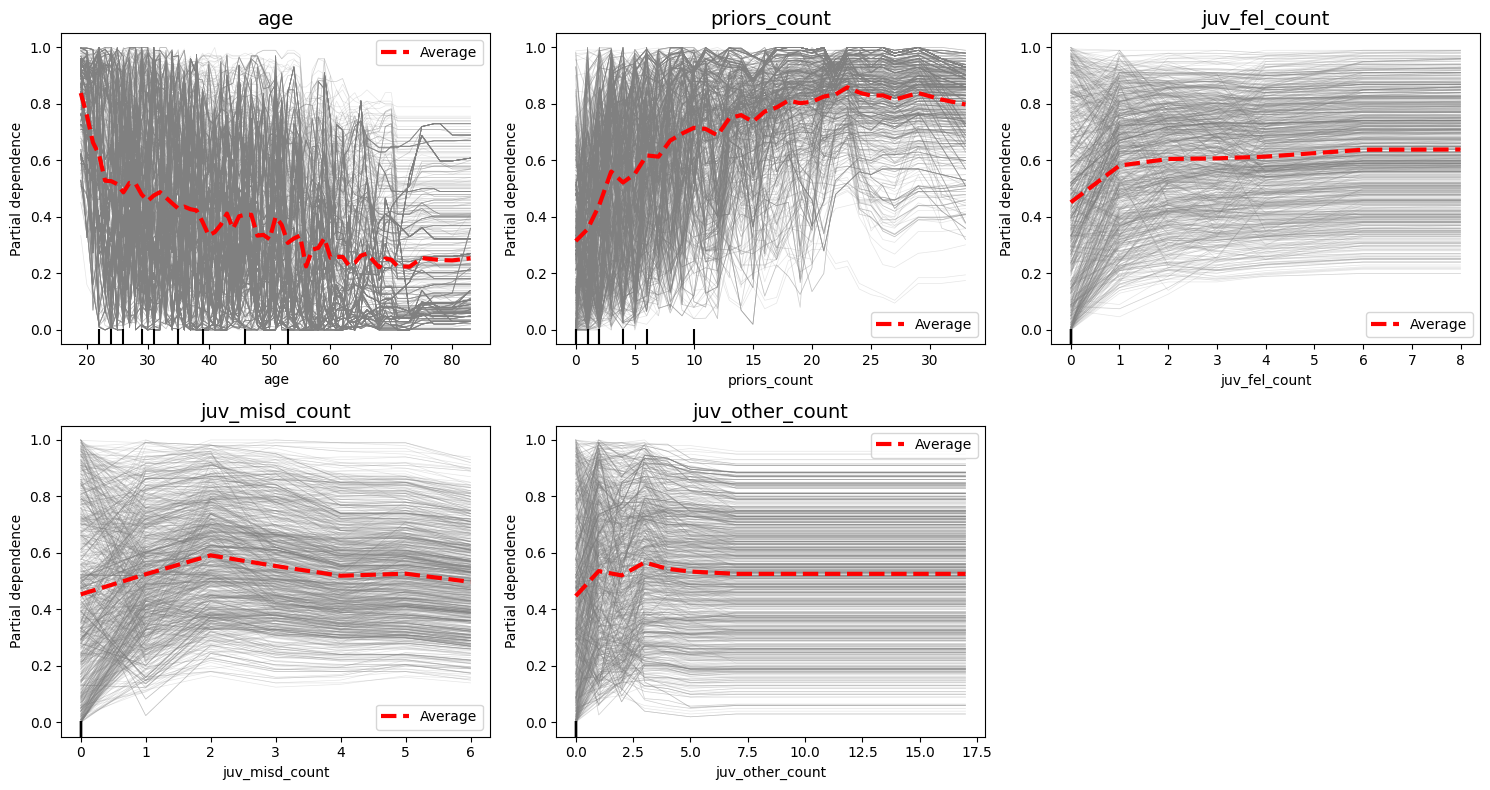

age [62 28 57 19 37 23 26 63 56 30 35 41 34 52 22 27 21 42 33 54 48 29 25 59
 69 47 32 36 45 39 51 20 55 49 24 53 31 43 44 50 61 40 58 65 77 60 46 80
 38 70 66 83 78 75 71 64 68 73]
sex [1 0]
race [2 0 5 3 4 1]
priors_count [ 0  1  8  4  2 16 12  3 21 13  5 14 22  7  6 17 15 10  9 29 11 20 24 18
 25 33 19 27 26 31 23]
juv_fel_count [0 1 2 8 3 6 4]
juv_misd_count [0 1 2 3 4 6 5]
juv_other_count [ 0  1  2  4  3  5  7 17]
c_charge_degree [0 1]


In [7]:
# code generated and debugged using Perplexity 9/26 18:50
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
categorical_features = ['sex', 'race', 'c_charge_degree']
numeric_features = [f for f in features if f not in categorical_features]

# plot setting
n_features = len(numeric_features)
ncols = 3
nrows = (n_features + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# feature ICE and average (PDP)
for i, feature in enumerate(numeric_features):
    display = PartialDependenceDisplay.from_estimator(
        model_compas,
        X_test,
        [feature],
        kind='both',
        response_method='predict_proba',
        categorical_features=categorical_features,
        ax=axes[i],
        pd_line_kw={"color":"red", "linewidth":3, "label":"Average"},
        ice_lines_kw={"color":"gray", "alpha":0.2}
    )
    axes[i].set_title(feature, fontsize=14)
    axes[i].legend()

# remove redundant subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

for col in features:
    print(col, X_test[col].unique())

### Findings (No AI)

According to ICE curves, the findings are as follow:
1. Age causes huge perturbation before age of 70 and almost causes no effect after age of 70;
2. Priors_count has stronger perturbation effect when it is low, and as the count exceeds 25, the effect is reduced to very small strength;
3. juv_fel_count, juv_misd_count and juv_other_count are similar, they all have stronger perturbation effect when small and lose effect after getting big.

According to PDP curves, the finds are as follow:
1. Age has a negative effect on the probability of recidivism. The curve is partial linear, and can be mainly devided into three parts. First part: under age 25, the probability of recidivism drops fast when age increases. Second part: 25-70 years old, the probs drops slowly by age increase. Third part: after 70, the age have almost no effect on probs.
2. Priors count has positive impact on probs of recidivism. The plot is like the upper part of S curve. The positive effect reduces as it increases.
3. Juv_fel_count, juv_misd_count and juv_other_count are similar. PDP for these three are partial linear. They increase the average probability of recidivism when small. Juv_fel_count still has small but steady positive contribution to avg probs after hitting 1; juv_misd_count has small but steady negative contribution to avg probs after reaching 2; and juv_other_count has nearly no effect after getting 5.

From above, this result could indicate that, among the numerical features, the model values the age, priors count and juv_fel_count as major contributors overall. And this generally aligns with the understanding of the recidivism case.



## 4. ALE

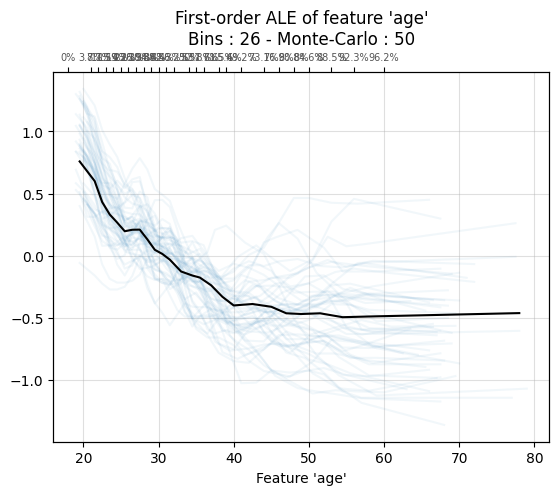

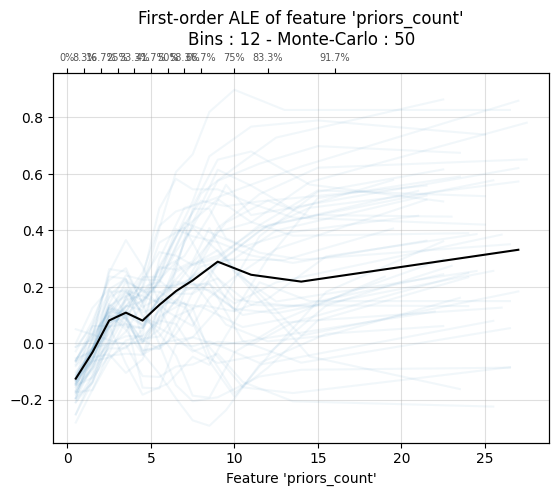

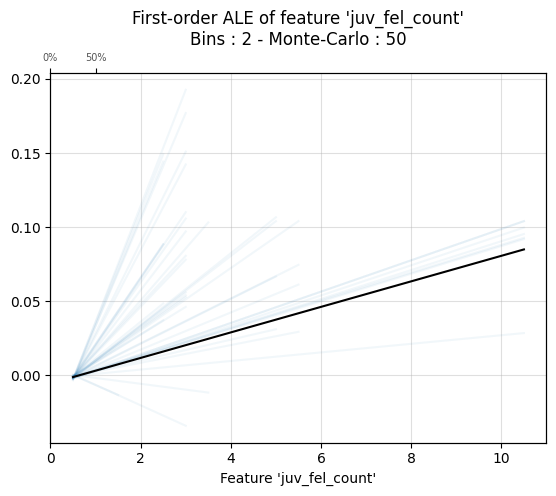

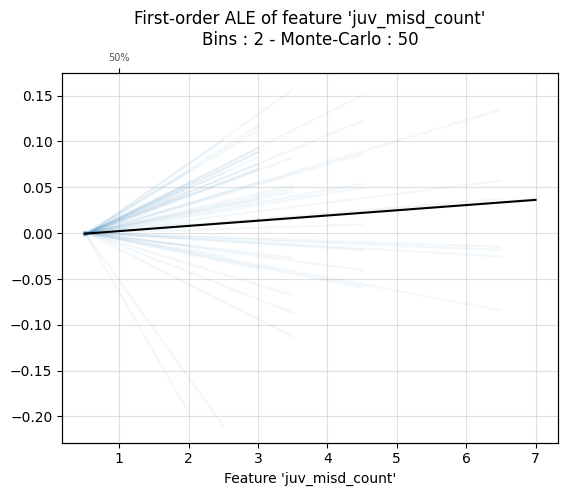

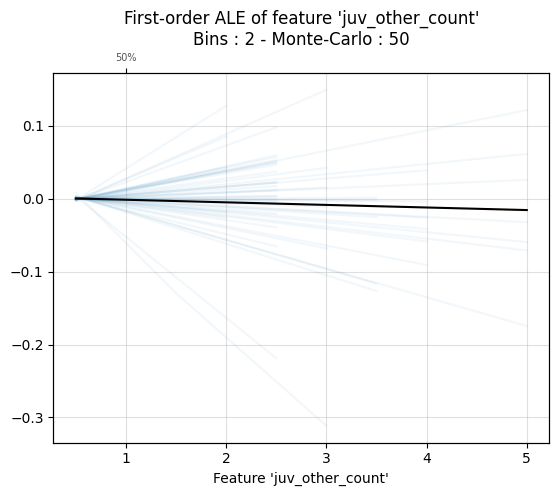

In [8]:
# first order, modified based on code from course notebook, no AI
from alepython import ale_plot
for feature in numeric_features:
  # Use default parameters for 1D Main Effect ALE Plot
  ale_plot(model_compas, X_train, feature, bins=30, monte_carlo=True)

In [9]:
# pip install PyALE

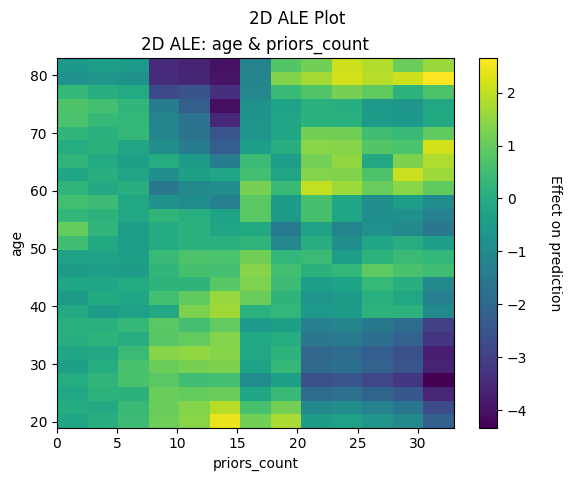

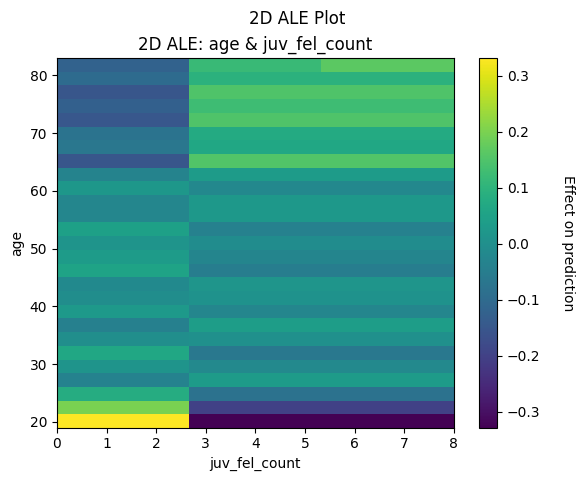

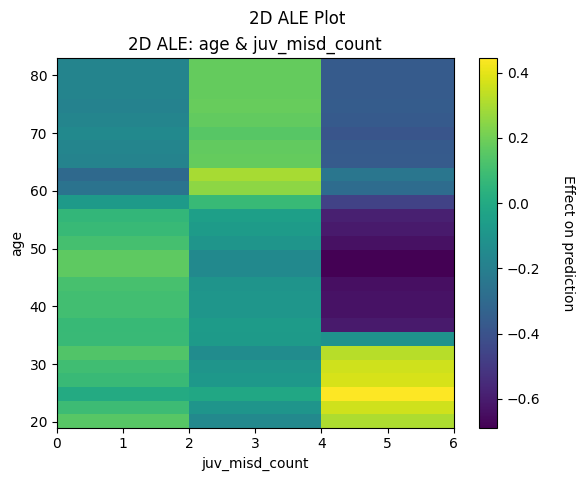

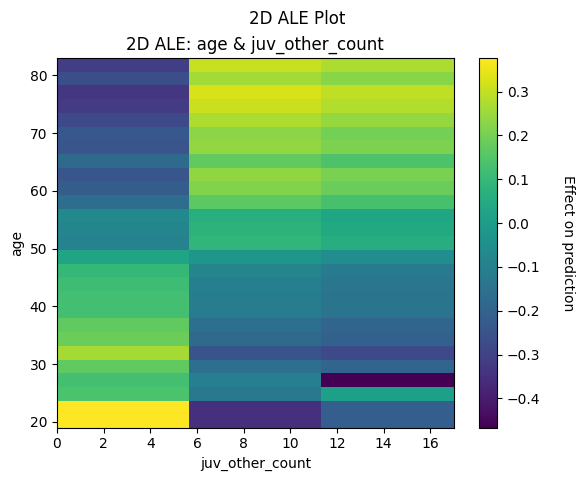

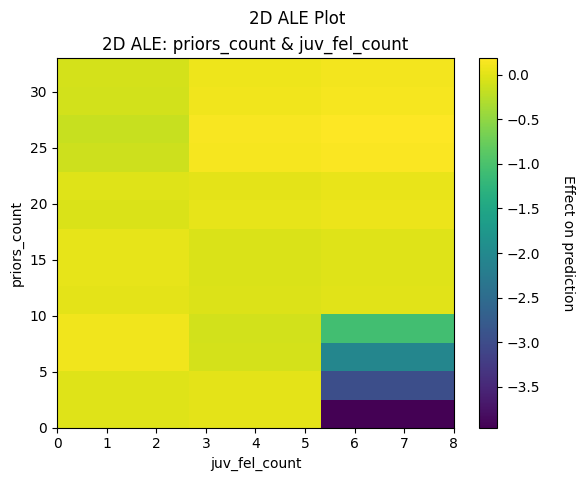

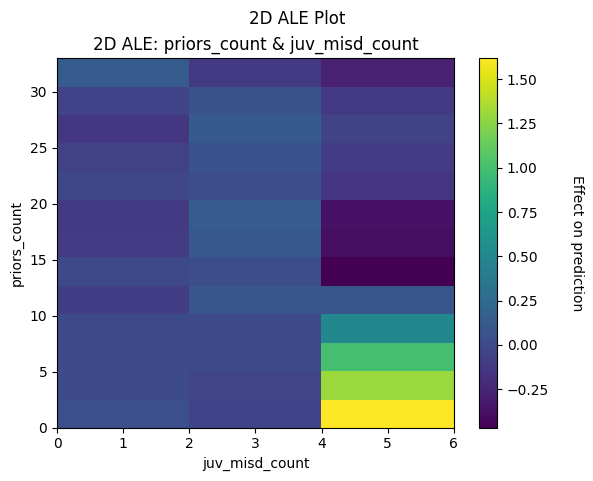

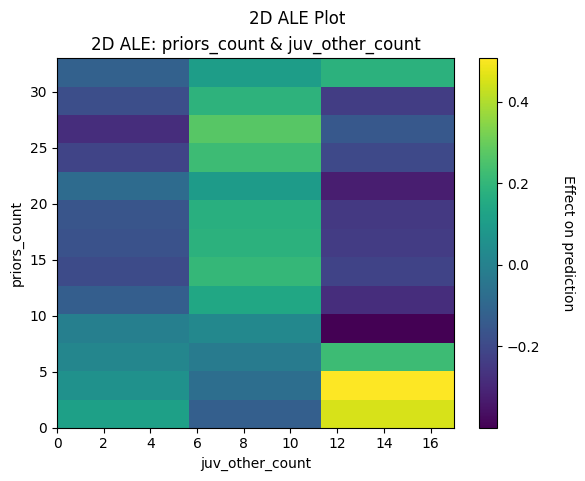

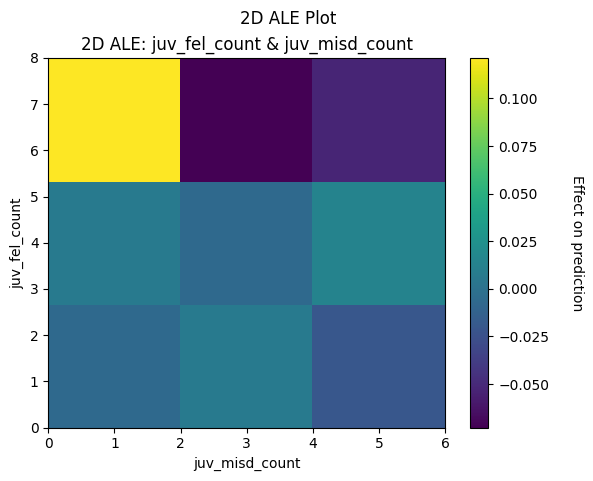

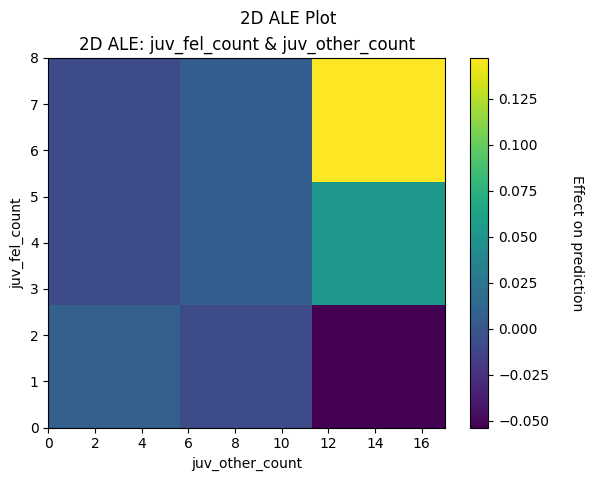

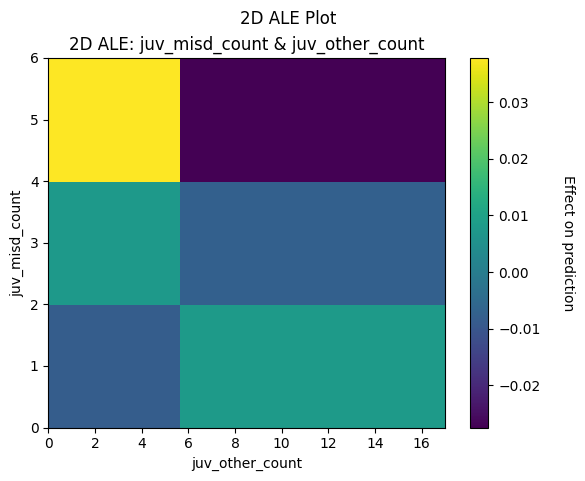

In [10]:
# second order ALE plot, generated by Perplexity Sep 26, 21:04
from PyALE import ale
import matplotlib.pyplot as plt
from itertools import combinations

for f1, f2 in combinations(numeric_features, 2):
    ale(
        X=X_test,                # pandas DataFrame
        model=model_compas,        # prediction function
        feature=[f1, f2],        # list of two feature names
        grid_size=30,            # number of bins per feature (adjust as needed)
        plot=True                # plot directly
    )
    plt.title(f'2D ALE: {f1} & {f2}')
    plt.show()

### ALE Findings (No AI)
From first order ALE plot:
1. Age has negative impact on probability of recidivism. The overall impact is large before age of 40 and the impact is close to none after that.
2. Priors count has large overall postitive effect below 10, and mild effect after that.
3. Juv_fel_count and juv_misd_count both have positive effect no matter the count; while juv_other_count has mild negative effect regradless of the count.

From second order ALE plot:
1. When age is small but priors is big, there is huge negative effect; when priors count between 7 and 15, high age has negative effect.
2. When age is small, small juv_fel_count has huge postive effect below 3, and huge negative effect larger than 3; when juv_fel_count is below 3, the larger the age, the more negative effect is observed; when juv_fel_count is above 3, the less the age, the the more negative effect is observed.
3. For juv_misd_count bigger than 4, small age has strong positive impact and midium age has strong negative impact.
4. For young age, juv_other_count has strong positive impact below 6 and strong negative impact after that.
5. For all priors_count, only large juv_fel_count can offset the strong positive impact. But this is not reasonable, probably the data is missing for this local region.
6. For large juv_other_count, the larger the juv_fel_count, the more positive impact; for large juv_misd_count, the smaller the juv_other_count, the more positive impact; for large juv_fel_count, the less juv_misd_count, the more positive impact.

## PDP & ALE Plots Comparision (No AI)

1. Age and priors_count effect is similar for both methods overall, both methods revieled that the age has negative impact, but the effectiveness range partition is slightly different; while priors_count has positive effect, with similar curve shape.
2. Both methods accept that juv_fel_count has positive effect overall, but PDP indicates that this feature has more impact when it is small while ALE indicates this feature has same impact regardless of the count. Similar observations applies for juv_misd_count and juv_other_count.
3. Both methods accept that juv_misd_count and juv_other_count has minor effect overall but they assign different overall impact effect and direction differently.




## Discussion on correlation in exploratory findings and impact it has on result (if any) (No AI)

From data exploration, the correlation coefficient absolute values are all below 0.3, the correlation between the features are not strong, therefore, this part is not applicable.